In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [72]:
data = pd.read_excel("/content/WLS_train_data.xlsx")

In [73]:
Y_train = data[['Y']].values
X_train = data[['X']].values

In [56]:
ones = np.ones((X_train.shape[0],1))
X_train = np.hstack((ones, X_train))

In [57]:
sigma = data['Standar Deviation'].values
weights = 1 / (sigma**2)
W = np.diag(weights)

In [58]:
beta_wls = np.linalg.inv(X_train.T @ W @ X_train) @ X_train.T @ W @ Y_train

beta_ols = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ Y_train

In [59]:
test = pd.read_excel("/content/WLS Test_data.xlsx")
Y_test = test[['Y']].values
X_test = test[['X']].values
ones = np.ones((X_test.shape[0],1))
X_test = np.hstack((ones, X_test))

In [67]:
Y_pred_wls_test = X_test @ beta_wls

Y_pred_ols_test = X_test @ beta_ols

res_wls = Y_test - Y_pred_wls_test

res_ols = Y_test - Y_pred_ols_test

In [61]:
beta_ols

array([[0.09733629],
       [0.36473142]])

In [62]:
beta_wls

array([[0.1005584 ],
       [0.34866921]])

In [63]:
res_wls.shape

(40, 1)

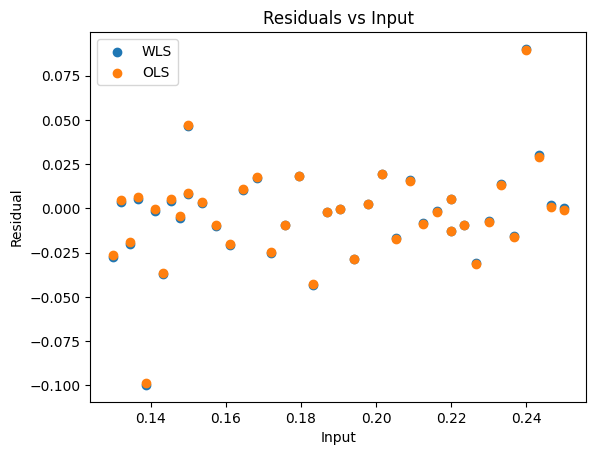

In [71]:
#residuals vs input for both OLS and WLS

plt.scatter(X_test[:,1], res_wls, label="WLS")
plt.scatter(X_test[:,1], res_ols, label="OLS")

plt.xlabel("Input")
plt.ylabel("Residual")
plt.legend()
plt.title("Residuals vs Input")
plt.show()

The residuals for both OLS and WLS appear randomly scattered around zero with approximately constant variance across input values. No funnel-shaped pattern is observed, indicating absence of heteroscedasticity. Since the noise variance is nearly constant in the dataset, WLS does not provide significant improvement over OLS. The residual distributions for both models are nearly identical.

Geometric Interpretation
OLS - Projection of Y onto column space of X.
WLS - This is a weighted norm.

In [54]:
#OLS → spherical error contours

#WLS → elliptical contours

model output vs expected output for train data

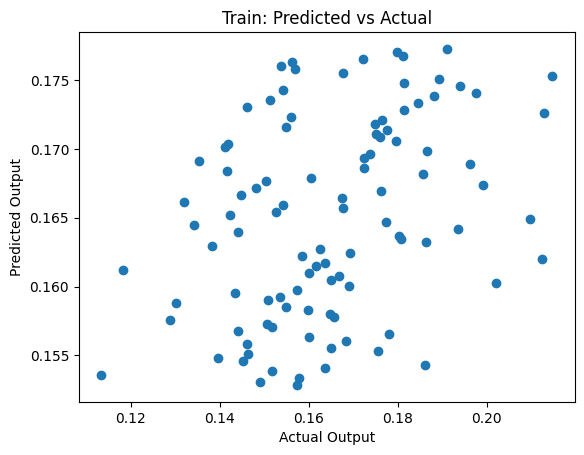

In [66]:
Y_pred_wls_train = X_train @ beta_wls

plt.scatter(Y_train, Y_pred_wls_train)
plt.xlabel("Actual Output")
plt.ylabel("Predicted Output")
plt.title("Train: Predicted vs Actual")
plt.show()

model output vs expected output for test data

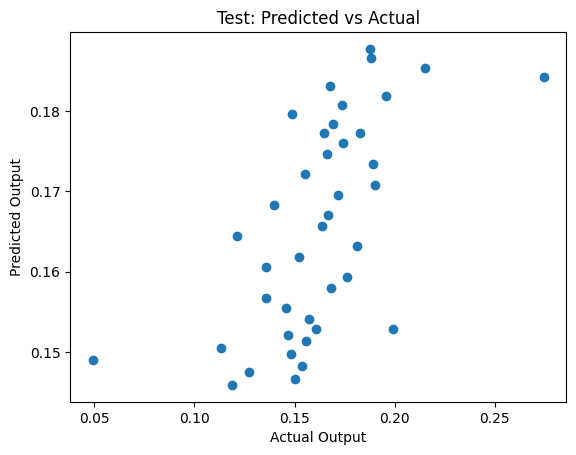

In [69]:
plt.scatter(Y_test, Y_pred_wls_test)
plt.xlabel("Actual Output")
plt.ylabel("Predicted Output")
plt.title("Test: Predicted vs Actual")
plt.show()

The predicted vs actual scatter plot shows that the predicted values closely align with the ideal 45° line for both training and test datasets. This indicates that the model generalizes well and does not suffer from significant overfitting. Since noise variance is approximately constant, WLS does not significantly outperform OLS.